EN ESTE NOTEBOOK:

Usamos df1 ('datos_embarazo_imp2.csv') con las siguientes variables: 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'ratio_sflt1_plgf', 'valor_plgf', 'eg_deter_sflt1_plgf', 'tas_1tri', 'tad_1tri', 'edad_materna_gest'.

- Hacer un análisis de correlaciones: señalar las variables con alta correlación
- Hacer un análisis de la distribución: señalar qué transformación aplicar en las variables asimétricas

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('datos_embarazo_imp2.csv')

In [3]:
df1.loc[df1['id'] == 487, 'fecha_ult_deter'] = '2021-02-18'
df1.loc[df1['id'] == 487, 'eg_deter_sflt1_plgf'] = '39.3'

/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_10423/782644410.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '39.3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df1.loc[df1['id'] == 487, 'eg_deter_sflt1_plgf'] = '39.3'


In [4]:
# Seleccionamos solo las variables numéricas
df1 = df1[['id',
    'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 
    'imc_ini_gest', 'peso_rn', 'apgar_1min', 'apgar_5min', 
    'apgar_10min', 'eg_parto', 'ratio_sflt1_plgf', 'valor_plgf', 
    'eg_deter_sflt1_plgf', 'tas_1tri', 'tad_1tri', 'edad_materna_gest'
]]

In [5]:
df1['eg_deter_sflt1_plgf']

0      35.0
1      37.2
2      33.0
3      32.8
4      40.5
       ... 
451    31.8
452    36.8
453    36.9
454    32.9
455    39.5
Name: eg_deter_sflt1_plgf, Length: 456, dtype: object

In [6]:
print(df1.loc[df1['id'] == 487])

        id  peso_ini_gest  peso_fin_gest  aumento_peso_gest  talla  \
317  487.0           65.0           74.0                9.0  170.0   

     imc_ini_gest  peso_rn  apgar_1min  apgar_5min  apgar_10min  eg_parto  \
317         22.49   2920.0        10.0        10.0         10.0      39.3   

     ratio_sflt1_plgf  valor_plgf eg_deter_sflt1_plgf  tas_1tri  tad_1tri  \
317                 0           2                39.3     113.0      66.0   

     edad_materna_gest  
317              35.82  


In [7]:
df1.head()

,id,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,ratio_sflt1_plgf,valor_plgf,eg_deter_sflt1_plgf,tas_1tri,tad_1tri,edad_materna_gest
0,1.0,57.6,68.0,10.4,166.0,20.90,1970.0,8.0,9.0,10.0,34.9,2,2,35.0,113.878694,74.361275,33.08
1,2.0,54.0,60.0,6.0,163.0,20.32,1980.0,9.0,10.0,10.0,37.3,2,2,37.2,113.546264,74.470466,42.81
2,4.0,71.0,82.0,11.0,157.0,28.80,1380.0,6.0,8.0,9.0,33.8,3,2,33.0,118.809048,77.154254,38.36
3,5.0,46.0,50.4,4.4,156.0,18.90,2950.0,9.0,10.0,10.0,39.0,0,0,32.8,108.000000,65.000000,30.72
4,8.0,55.8,70.0,14.2,157.0,22.64,3350.0,9.0,10.0,10.0,40.6,0,0,40.5,113.000000,80.000000,32.56


# Análisis de correlaciones

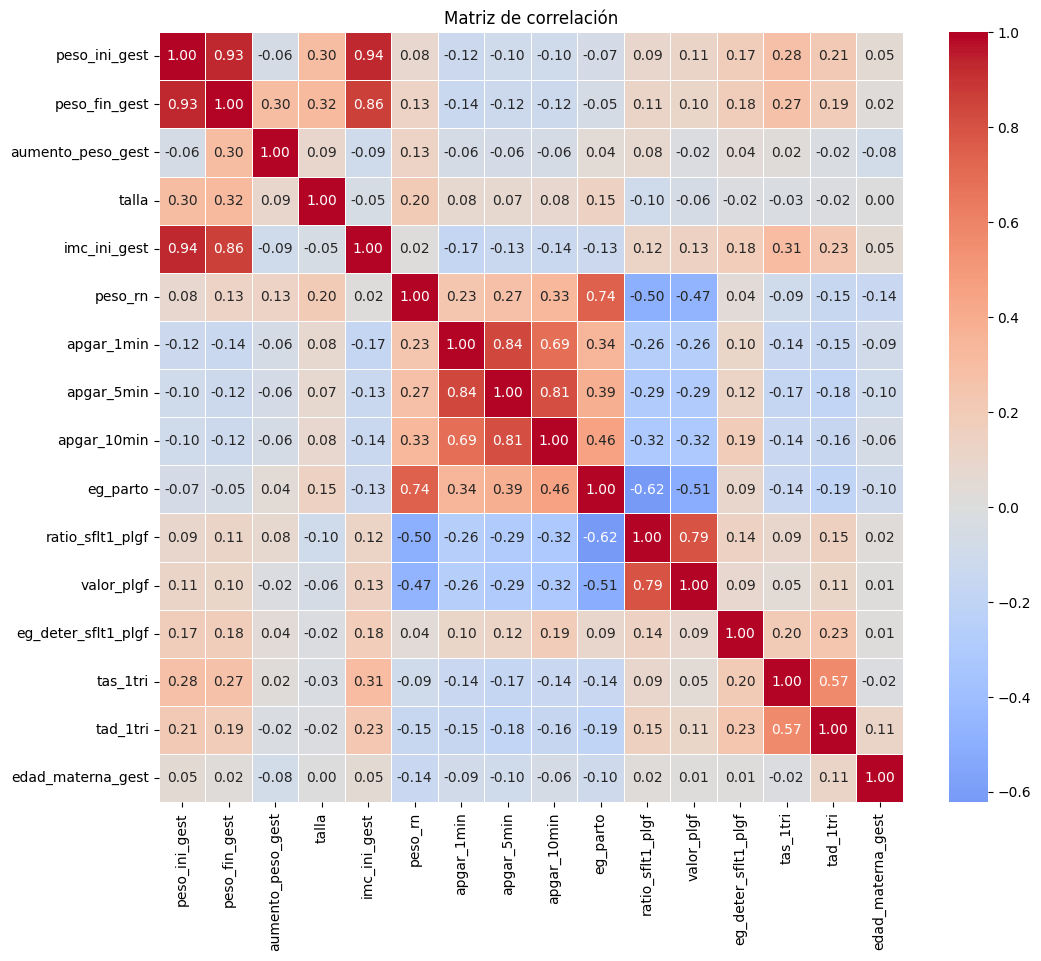

In [8]:
# Calculamos la matriz de correlación
# Usamos .drop para ignorar la columna 'id' solo en este paso
matriz_correlacion = df1.drop(columns=['id'], errors='ignore').corr()

plt.figure(figsize=(12, 10))

# Mapa de calor
sns.heatmap(matriz_correlacion, 
            annot=True,          
            fmt=".2f",           
            cmap='coolwarm',     # Escala de colores (rojo positivo, azul negativo)
            center=0,            # El blanco será el 0
            linewidths=.5)       # Añade una pequeña línea entre celdas

plt.title('Matriz de correlación')
plt.show()

INTERPRETACIÓN:

Variables altamente correlacionadas (positivamente): 
- 'peso_ini_gest', 'peso_fin_gest' y 'imc_ini_gest' (esto es normal)
- 'peso_rn' y 'eg_parto' (esto es normal)
- 'apgar1', 'apgar5' y 'apgar10' (esto es normal)
- 'ratio_sflt1_plgf' y 'valor_plgf' (esto creemos que **NO** es normal): es una división; a mayor denominador menor valor.
- 'tas_1tri' y 'tad_1tri' (esto es normal): ambas miden la presión arterial

Variables corrrelacionadas (negativamente):
- 'ratio_sflt1_plgf' y 'eg_parto' (esto es normal)
- 'ratio_sflt1_plgf' y 'peso_rn' (esto es normal): el ratio sFlt-1/PlGF es un indicador de estrés placentario y riesgo de preeclampsia. Si el ratio sube indica peor función de la placenta, que provoca parto prematuro y bebé con menos peso
- 'valor_plgf' y 'eg_parto' (esto creemos que **NO** es normal): niveles altos de PlGF se asocian con embarazos que llegan a término y viceversa
- 'valor_plgf' y 'peso_rn' (esta creemos que **NO** es normal)

# Análisis de distribuciones

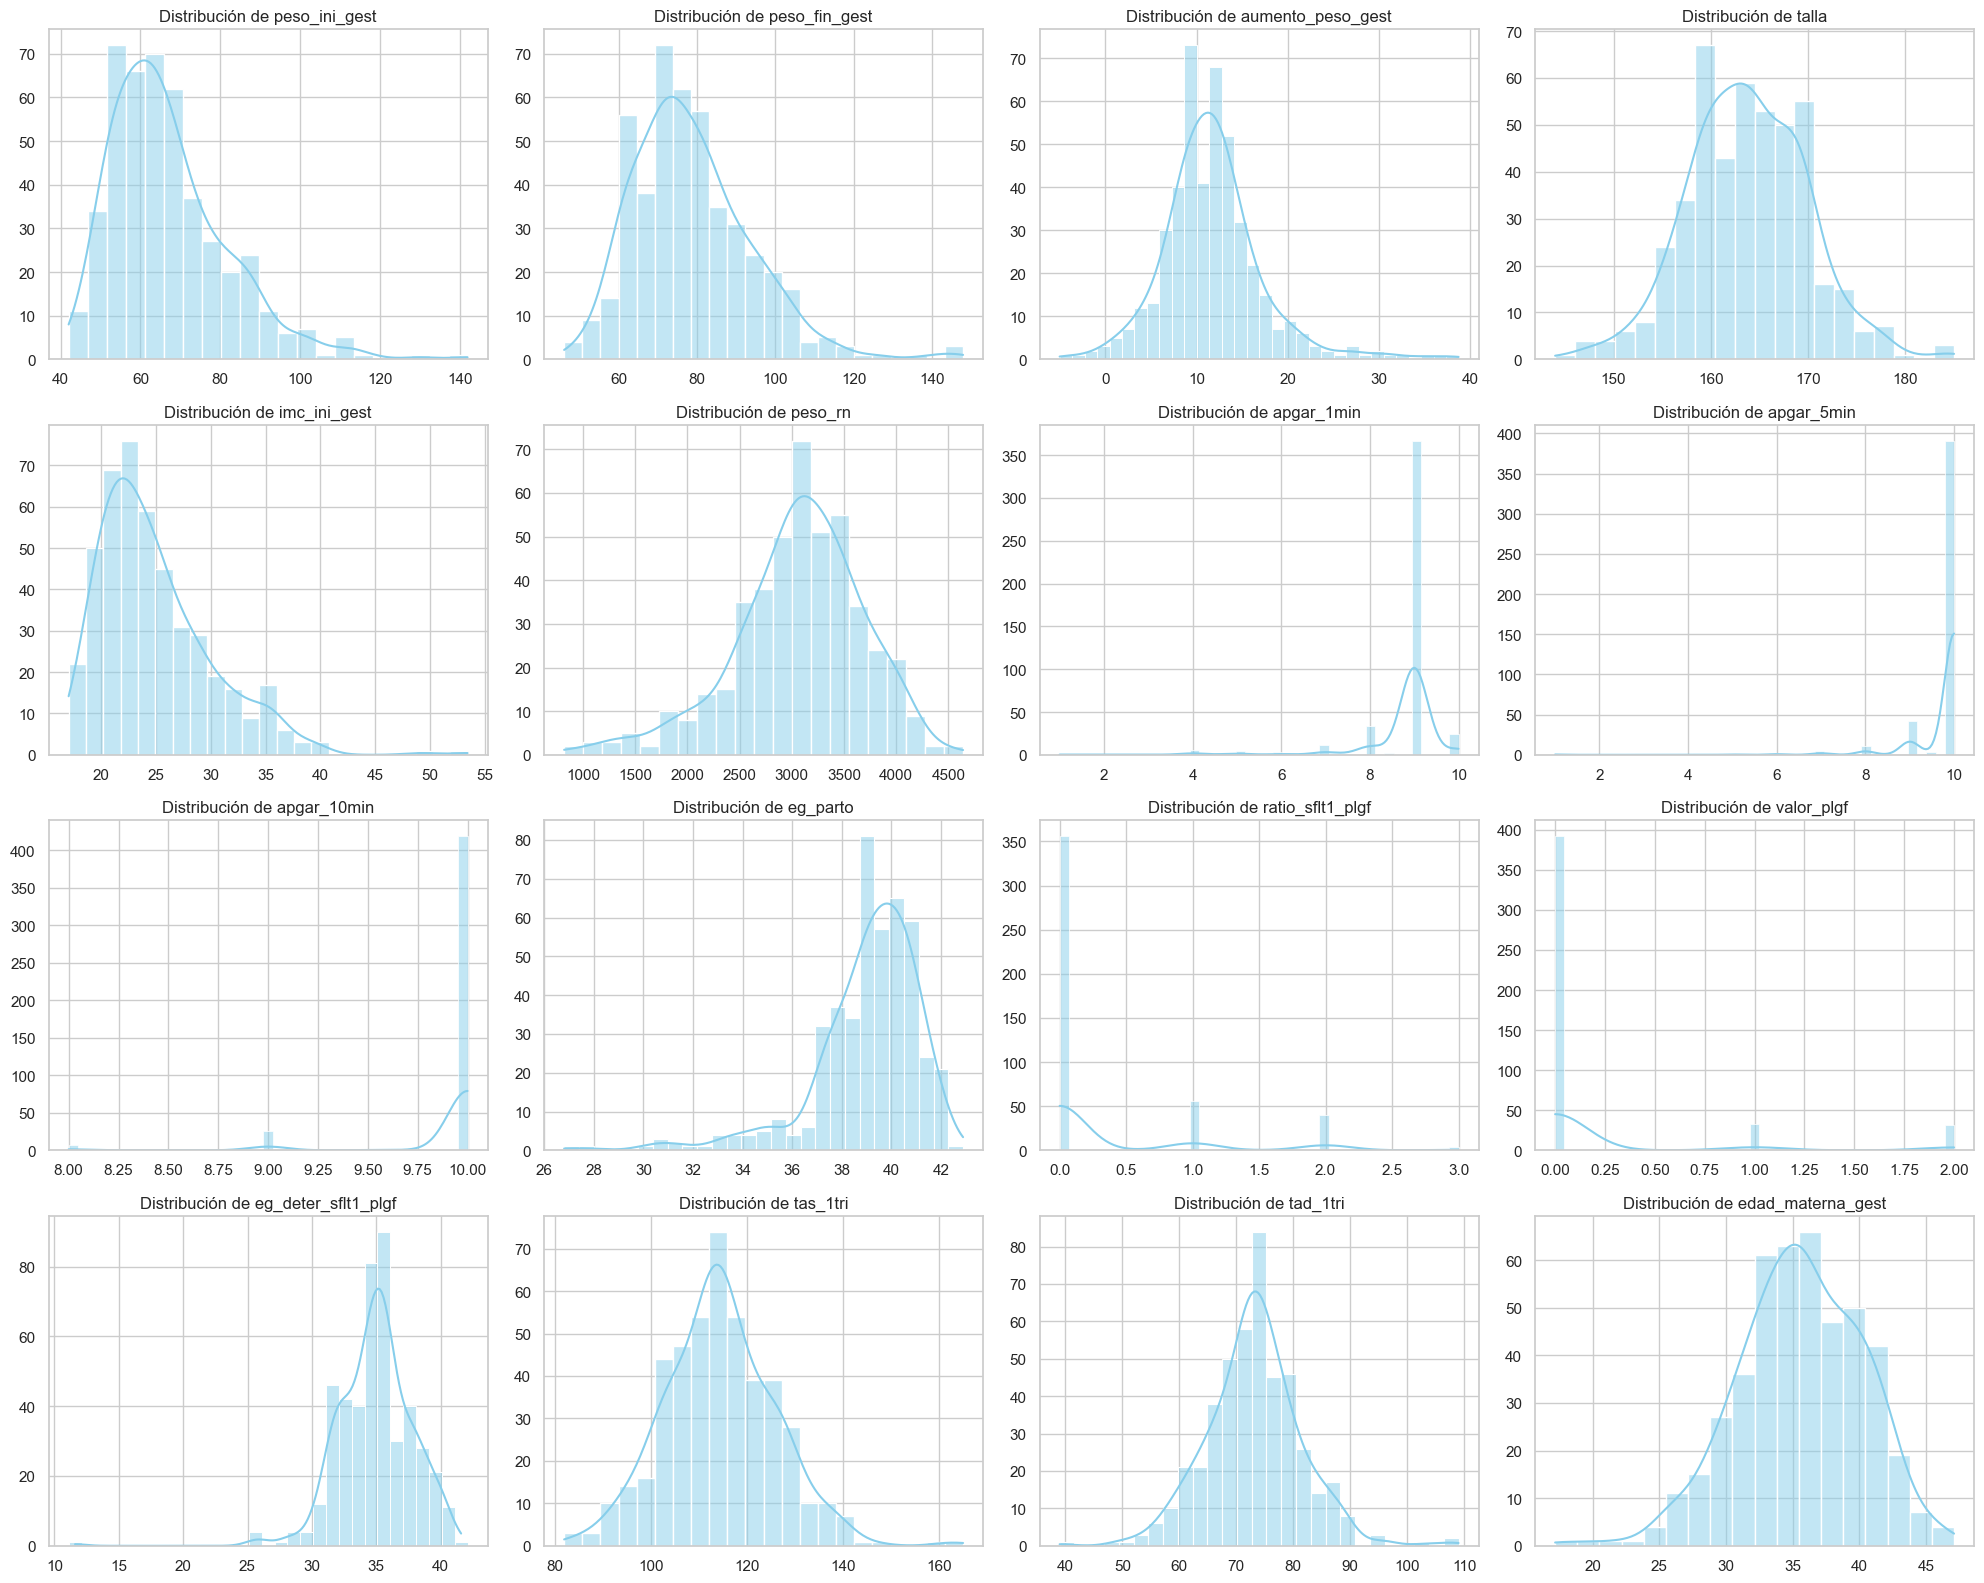

In [9]:
columnas_a_graficar = df1.columns.drop('id', errors='ignore')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten() 

# Iteramos sobre cada columna de df1 para graficar su distribución
for i, col in enumerate(columnas_a_graficar):
    sns.histplot(df1[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Ajustamos el diseño para que no se solapen los gráficos
plt.tight_layout()
plt.show()

INTERPRETACIÓN:

**Variables (cuasi)simétricas:**
- 'talla', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'aumento_peso_gest'

Esto es lógico en los márgenes de la variabilidad biológica de la población adulta

**Variables asimétricas a la derecha:**
- 'ratio_sflt1_plgf', 'valor_plgf', 'eg_deter_sflt1_plgf'

Esto es lógico porque el ratio sflt1/plgf suele dispararse solo en casos patológicos.

*No entiendo por qué valor_plgf es asimétrica a la dcha y no a la izq si es inversamente proporcional a ratio.*

- 'imc_ini_gest', 'peso_ini_gest' y 'peso_fin_gest' tienen asimetría a la derecha más leve. Se interpreta que la población estudiada está en rango de peso normal o sobrepeso

**Variables asimétricas a la izquierda:**
- 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'peso_rn'

Esto es lógico porque lo normal es que los bebés nazcan sanos (apgar altos) y a término, ocn peso suficiente.

TRANSFORMACIONES:

A las variables asimétricas a la derecha 'ratio_sflt1_plgf' y 'valor_plgf' se le puede aplicar la transformación logarítmica para comprimir los valores grandes. Como en ambas variables hay valores que son 0, hay que aplicar el cambio y = log(x+1)

A las variables ligeramente asimétricas a la derecha 'imc_ini_gest', 'peso_ini_gest' y 'peso_fin_gest' se le puede aplicar la transformación y = sqrt(x), que comprime los valores grandes pero es menos agresiva que la transformación logarítmica

A las variables asimétricas a la izquierda 'eg_parto' y 'peso_rn' se les puede aplciar la transformación logarítmica inversa. Quizás a las variables 'apgar_1min', 'apgar_5min', 'apgar_10min', le podríamos aplicar la transformación cuadrática inversa, ya que son valores pequeños.

# DUDAS
- las cosas escritas en negrita en la parte de correlaciones